# Figure 6 (Panels D–F)

Sampling accuracy under three mutation models. Panels A–C are intentionally excluded.

## Setup

In [33]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
REPO_ROOT = Path.cwd()
print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a figure in PDF, PNG, and EPS formats.

    Parameters:
    - fig: Figure
        Matplotlib figure to save.
    - stem: str
        Filename stem without an extension.
    - bbox_inches: str
        Bounding-box mode passed to Matplotlib.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a bold manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the annotation.
    - letter: str
        Panel letter.

    Returns:
    - None
        The annotation is added directly to ``ax``.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight="bold", va="top", ha="left")

from slide.direvo_functions import get_single_decay_rate_IK_v2
from slide_config import get_slide_data_dir

LANDSCAPE_NAMES = ("GB1", "TrpB", "TEV", "ParD3")
LANDSCAPE_COLORS = ("tab:orange", "tab:blue", "tab:green", "tab:red")
LANDSCAPE_MARKERS = ("o", "s", "^", "D")
MUTATION_MODELS = ("nuc_uniform", "nuc_h_sapiens_sym", "nuc_e_coli")
SLIDE_DATA_DIR = Path(get_slide_data_dir())
PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_sampling_75steps_processed.pkl"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Figure 6 Raw Products

The optional raw route generates all-start, 75-generation codon-aware decay curves.

In [34]:
required_raw_paths = {
    model: [
        SLIDE_DATA_DIR / f"decay_curves_{landscape}_{model}_m0.1_all_starts_75steps.pkl"
        for landscape in ("gb1", "trpb", "tev", "pard3")
    ]
    for model in MUTATION_MODELS
}

if OVERWRITE_RAW_PKL and not PLOT_ONLY:
    environment = os.environ.copy()
    environment.update({
        "SLIDE_NUM_STEPS": "75",
        "SLIDE_MUTATION_MODELS": ",".join(MUTATION_MODELS),
        "SLIDE_OVERWRITE": "1",
    })
    subprocess.run(
        [sys.executable, "scripts/empirical_landscape_decay_curves_codon_fast.py"],
        cwd=REPO_ROOT,
        env=environment,
        check=True,
    )

missing_raw_paths = [path for paths in required_raw_paths.values() for path in paths if not path.exists()]
print(f"Missing optional raw products: {len(missing_raw_paths)}")


Missing optional raw products: 12


## Figure 6 Processing

In [35]:
def load_figure6_sampling_payload() -> dict[str, object]:
    """Load the existing 75-generation Figure 6 sampling products.

    Returns:
    - dict[str, object]
        Sampling distributions and spectral reference values.
    """
    processed = get_processed_data_dir()
    data = {
        model: load_pickle(processed / f"trajectory_subsampling_{model}_75steps.pkl")
        for model in MUTATION_MODELS
    }
    spectral = load_pickle(processed / "spectral_rho_comparison.pkl")
    return {
        "data": data,
        "spectral": spectral,
        "params": {"M": 75, "bootstrap_replicates": 1000},
        "metadata": {"paper_reference": "Figure 6D-F"},
    }


def process_figure6_sampling_payload(
    raw_by_model: dict[str, list[np.ndarray]],
    spectral: dict[str, dict[str, float]],
    *,
    bootstrap_replicates: int = 1000,
    seed: int = 42,
) -> dict[str, object]:
    """Bootstrap fitted ruggedness over increasing numbers of starting points.

    Parameters:
    - raw_by_model: dict[str, list[np.ndarray]]
        Raw all-start decay arrays, ordered by empirical landscape for each model.
    - spectral: dict[str, dict[str, float]]
        Analytical ruggedness references by landscape and mutation model.
    - bootstrap_replicates: int
        Number of bootstrap estimates at every sampling depth.
    - seed: int
        NumPy random seed.

    Returns:
    - dict[str, object]
        Figure 6 sampling distributions and metadata.
    """
    rng = np.random.default_rng(seed)
    max_starts = (160_000, 160_000, 160_000, 8_000)
    processed: dict[str, list[list[np.ndarray]]] = {}
    for model, landscape_arrays in raw_by_model.items():
        model_results: list[list[np.ndarray]] = []
        for raw, maximum in zip(landscape_arrays, max_starts, strict=True):
            start_curves = np.asarray(raw, dtype=float).mean(axis=2).reshape(-1, 75)
            sample_counts = np.round(np.logspace(0, np.log10(maximum), 11)).astype(int)
            landscape_results = []
            for count in sample_counts:
                estimates = []
                for _ in range(bootstrap_replicates):
                    indices = rng.choice(start_curves.shape[0], size=int(count), replace=True)
                    curve = np.square(start_curves[indices]).mean(axis=0)
                    curve /= max(float(curve[0]), 1e-10)
                    estimates.append(float(get_single_decay_rate_IK_v2(curve, mut=0.1, num_steps=75)[0] / 2))
                landscape_results.append(np.asarray(estimates))
            model_results.append(landscape_results)
        processed[model] = model_results
    return {
        "data": processed,
        "spectral": spectral,
        "params": {"M": 75, "bootstrap_replicates": bootstrap_replicates, "seed": seed},
        "metadata": {"paper_reference": "Figure 6D-F"},
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure6_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    # Compatibility with the existing per-model 75-step processed caches.
    figure6_payload = load_figure6_sampling_payload()
else:
    if missing_raw_paths:
        listing = "\n".join(f"  - {path}" for path in missing_raw_paths)
        raise FileNotFoundError(f"Cannot rebuild Figure 6 processing; missing raw files:\n{listing}")
    raw_by_model = {}
    for model, paths in required_raw_paths.items():
        arrays = []
        for path in paths:
            with path.open("rb") as handle:
                arrays.append(np.asarray(pickle.load(handle)))
        raw_by_model[model] = arrays
    spectral = load_pickle(PROCESSED_DATA_DIR / "spectral_rho_comparison.pkl")
    figure6_payload = process_figure6_sampling_payload(raw_by_model, spectral)
    save_pickle(figure6_payload, PROCESSED_PATH)


## Individual Panels D–F

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


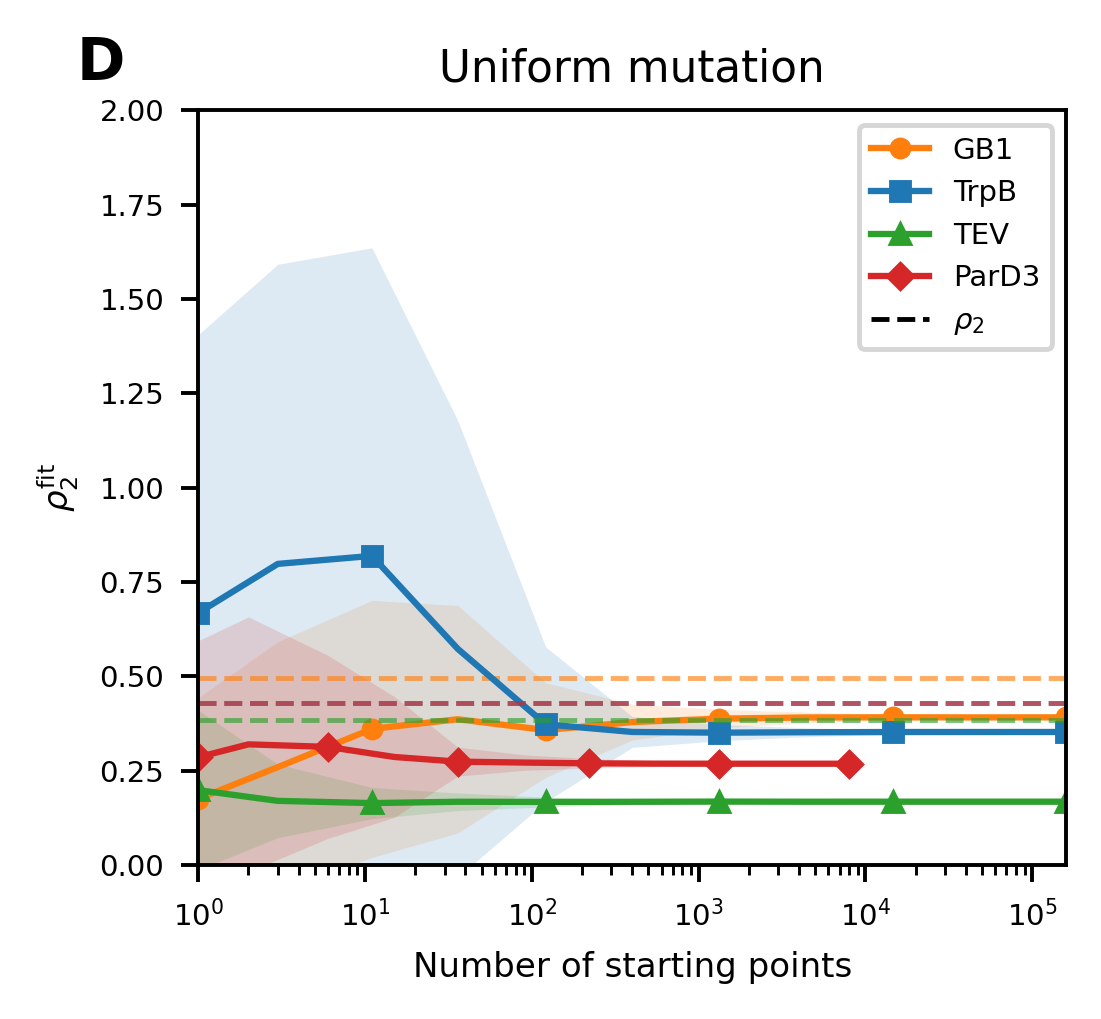

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


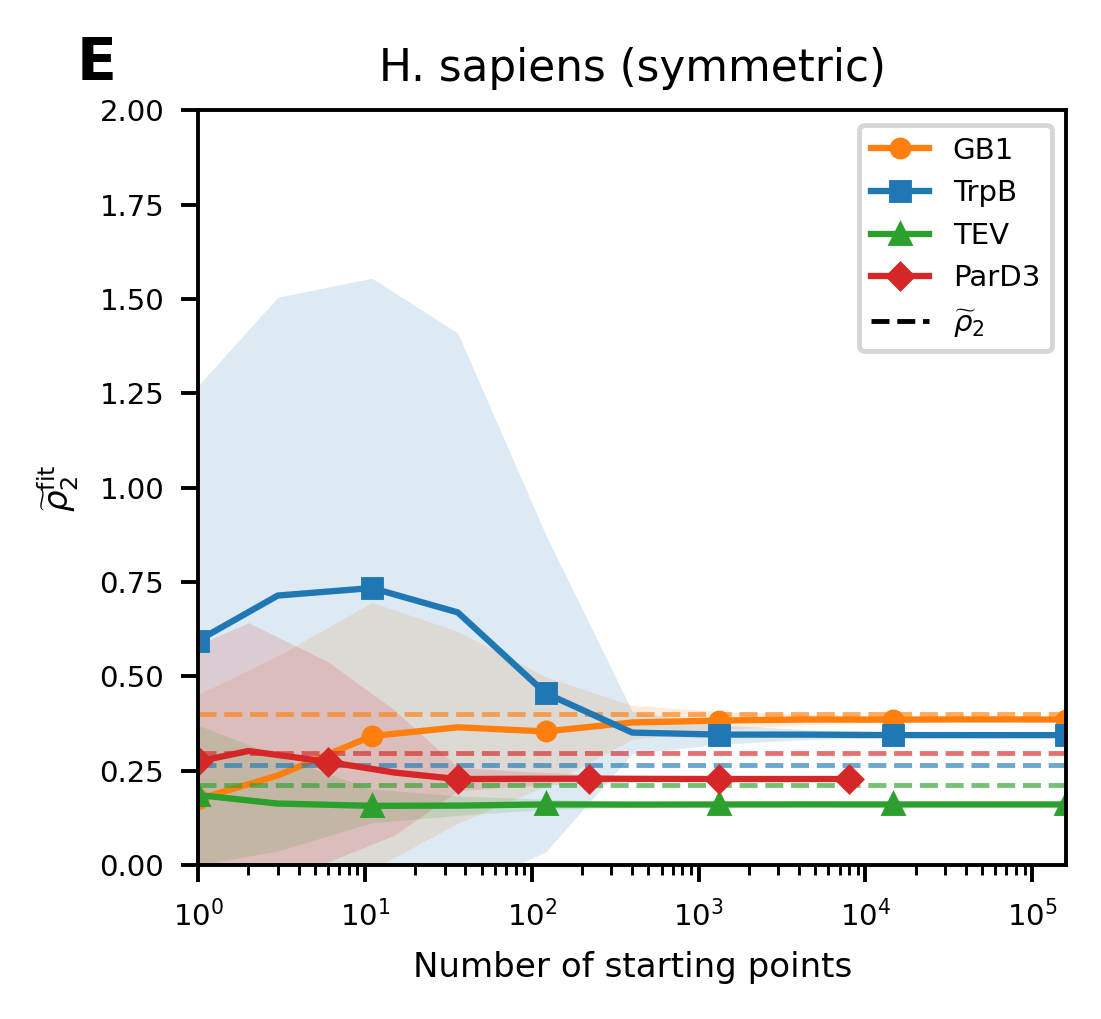

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


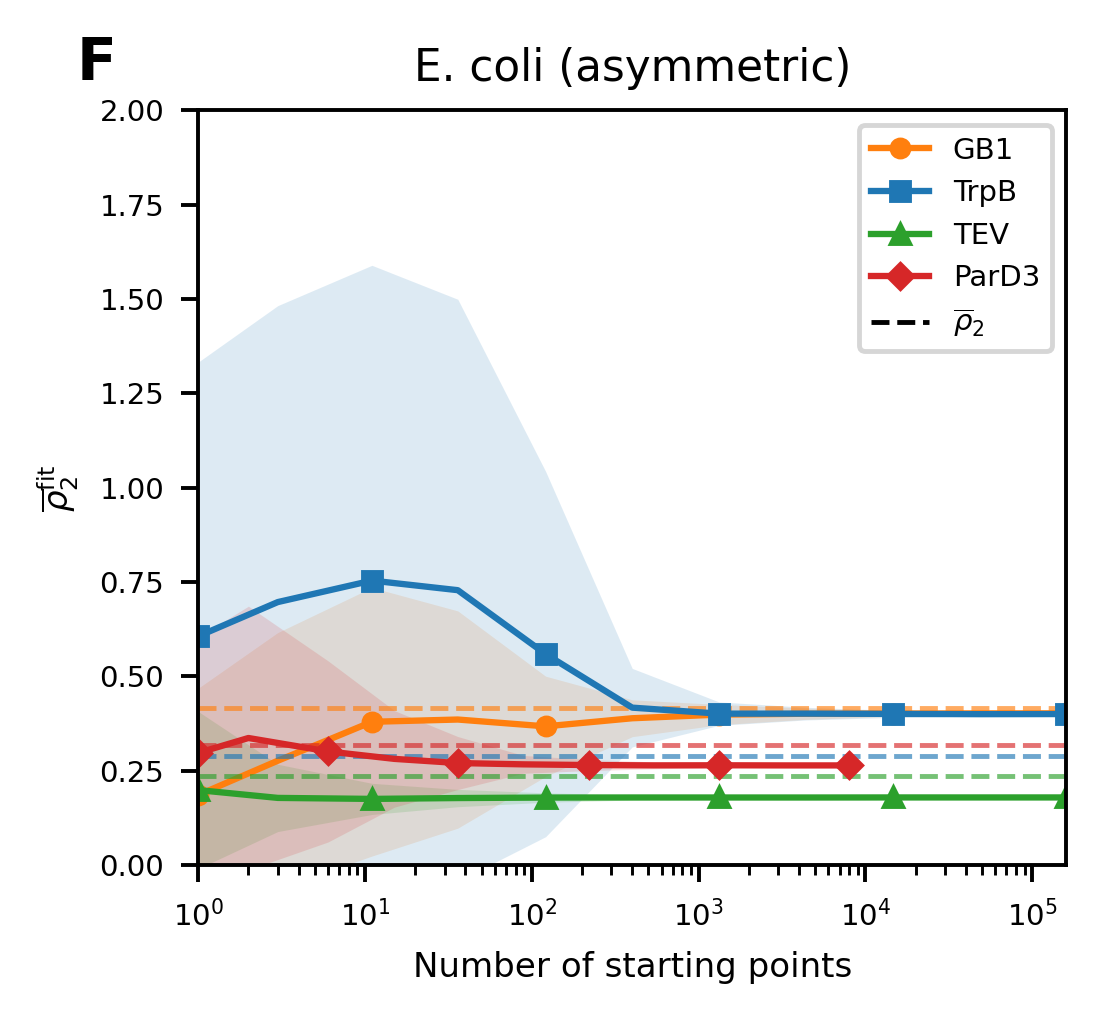

In [36]:
def plot_sampling_accuracy(ax: Axes, payload: dict[str, object], model: str) -> None:
    """Plot fitted ruggedness against the number of sampled starting points.

    Parameters:
    - ax: Axes
        Axis receiving the panel.
    - payload: dict[str, object]
        Figure 6 sampling payload.
    - model: str
        Mutation-model key.

    Returns:
    - None
        Lines and uncertainty bands are added to ``ax``.
    """
    titles = {
        "nuc_uniform": "Uniform mutation",
        "nuc_h_sapiens_sym": "H. sapiens (symmetric)",
        "nuc_e_coli": "E. coli (asymmetric)",
    }
    rho_labels = {
        "nuc_uniform": r"$\rho_2^{\mathrm{fit}}$",
        "nuc_h_sapiens_sym": r"$\widetilde{\rho}_2^{\mathrm{fit}}$",
        "nuc_e_coli": r"$\overline{\rho}_2^{\mathrm{fit}}$",
    }
    reference_labels = {
        "nuc_uniform": r"$\rho_2$",
        "nuc_h_sapiens_sym": r"$\widetilde{\rho}_2$",
        "nuc_e_coli": r"$\overline{\rho}_2$",
    }
    max_starts = (160_000, 160_000, 160_000, 8_000)
    model_data = payload["data"][model]  # type: ignore[index]
    spectral = payload["spectral"]  # type: ignore[assignment]
    for index, (name, maximum, color, marker) in enumerate(
        zip(LANDSCAPE_NAMES, max_starts, LANDSCAPE_COLORS, LANDSCAPE_MARKERS, strict=True)
    ):
        starts = np.round(np.logspace(0, np.log10(maximum), 11)).astype(int)
        values = model_data[index]
        means = np.asarray([np.mean(item) for item in values], dtype=float)
        stds = np.asarray([np.std(item) for item in values], dtype=float)
        ax.plot(starts, means, color=color, marker=marker, markersize=3.5,
                markevery=2, linewidth=1.3, label=name)
        ax.fill_between(starts, means - stds, means + stds, color=color, alpha=0.15, linewidth=0)
        reference_key = model if model != "nuc_e_coli" else "nuc_e_coli_sym"
        reference = spectral.get(name, {}).get(reference_key, np.nan)
        if np.isfinite(reference):
            ax.axhline(reference, color=color, linestyle="--", linewidth=1.0, alpha=0.65)
    ax.set_xscale("log")
    ax.set_title(titles[model], fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel("Number of starting points", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(rho_labels[model], fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(1, 160_000)
    ax.set_ylim(0, 2)
    ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
    reference_handle = mlines.Line2D(
        [], [], color="black", linewidth=1.0, linestyle="--", label=reference_labels[model]
    )
    handles, labels = ax.get_legend_handles_labels()
    handles.append(reference_handle)
    labels.append(reference_labels[model])
    ax.legend(
        handles=handles,
        labels=labels,
        fontsize=FIGURE_LEGEND_SIZE,
        frameon=True,
        loc="upper right",
        ncol=1,
    )


for letter, model in zip("DEF", MUTATION_MODELS, strict=True):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    plot_sampling_accuracy(ax, figure6_payload, model)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6{letter}")
    plt.show()


## Complete Figure 6 A–F

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


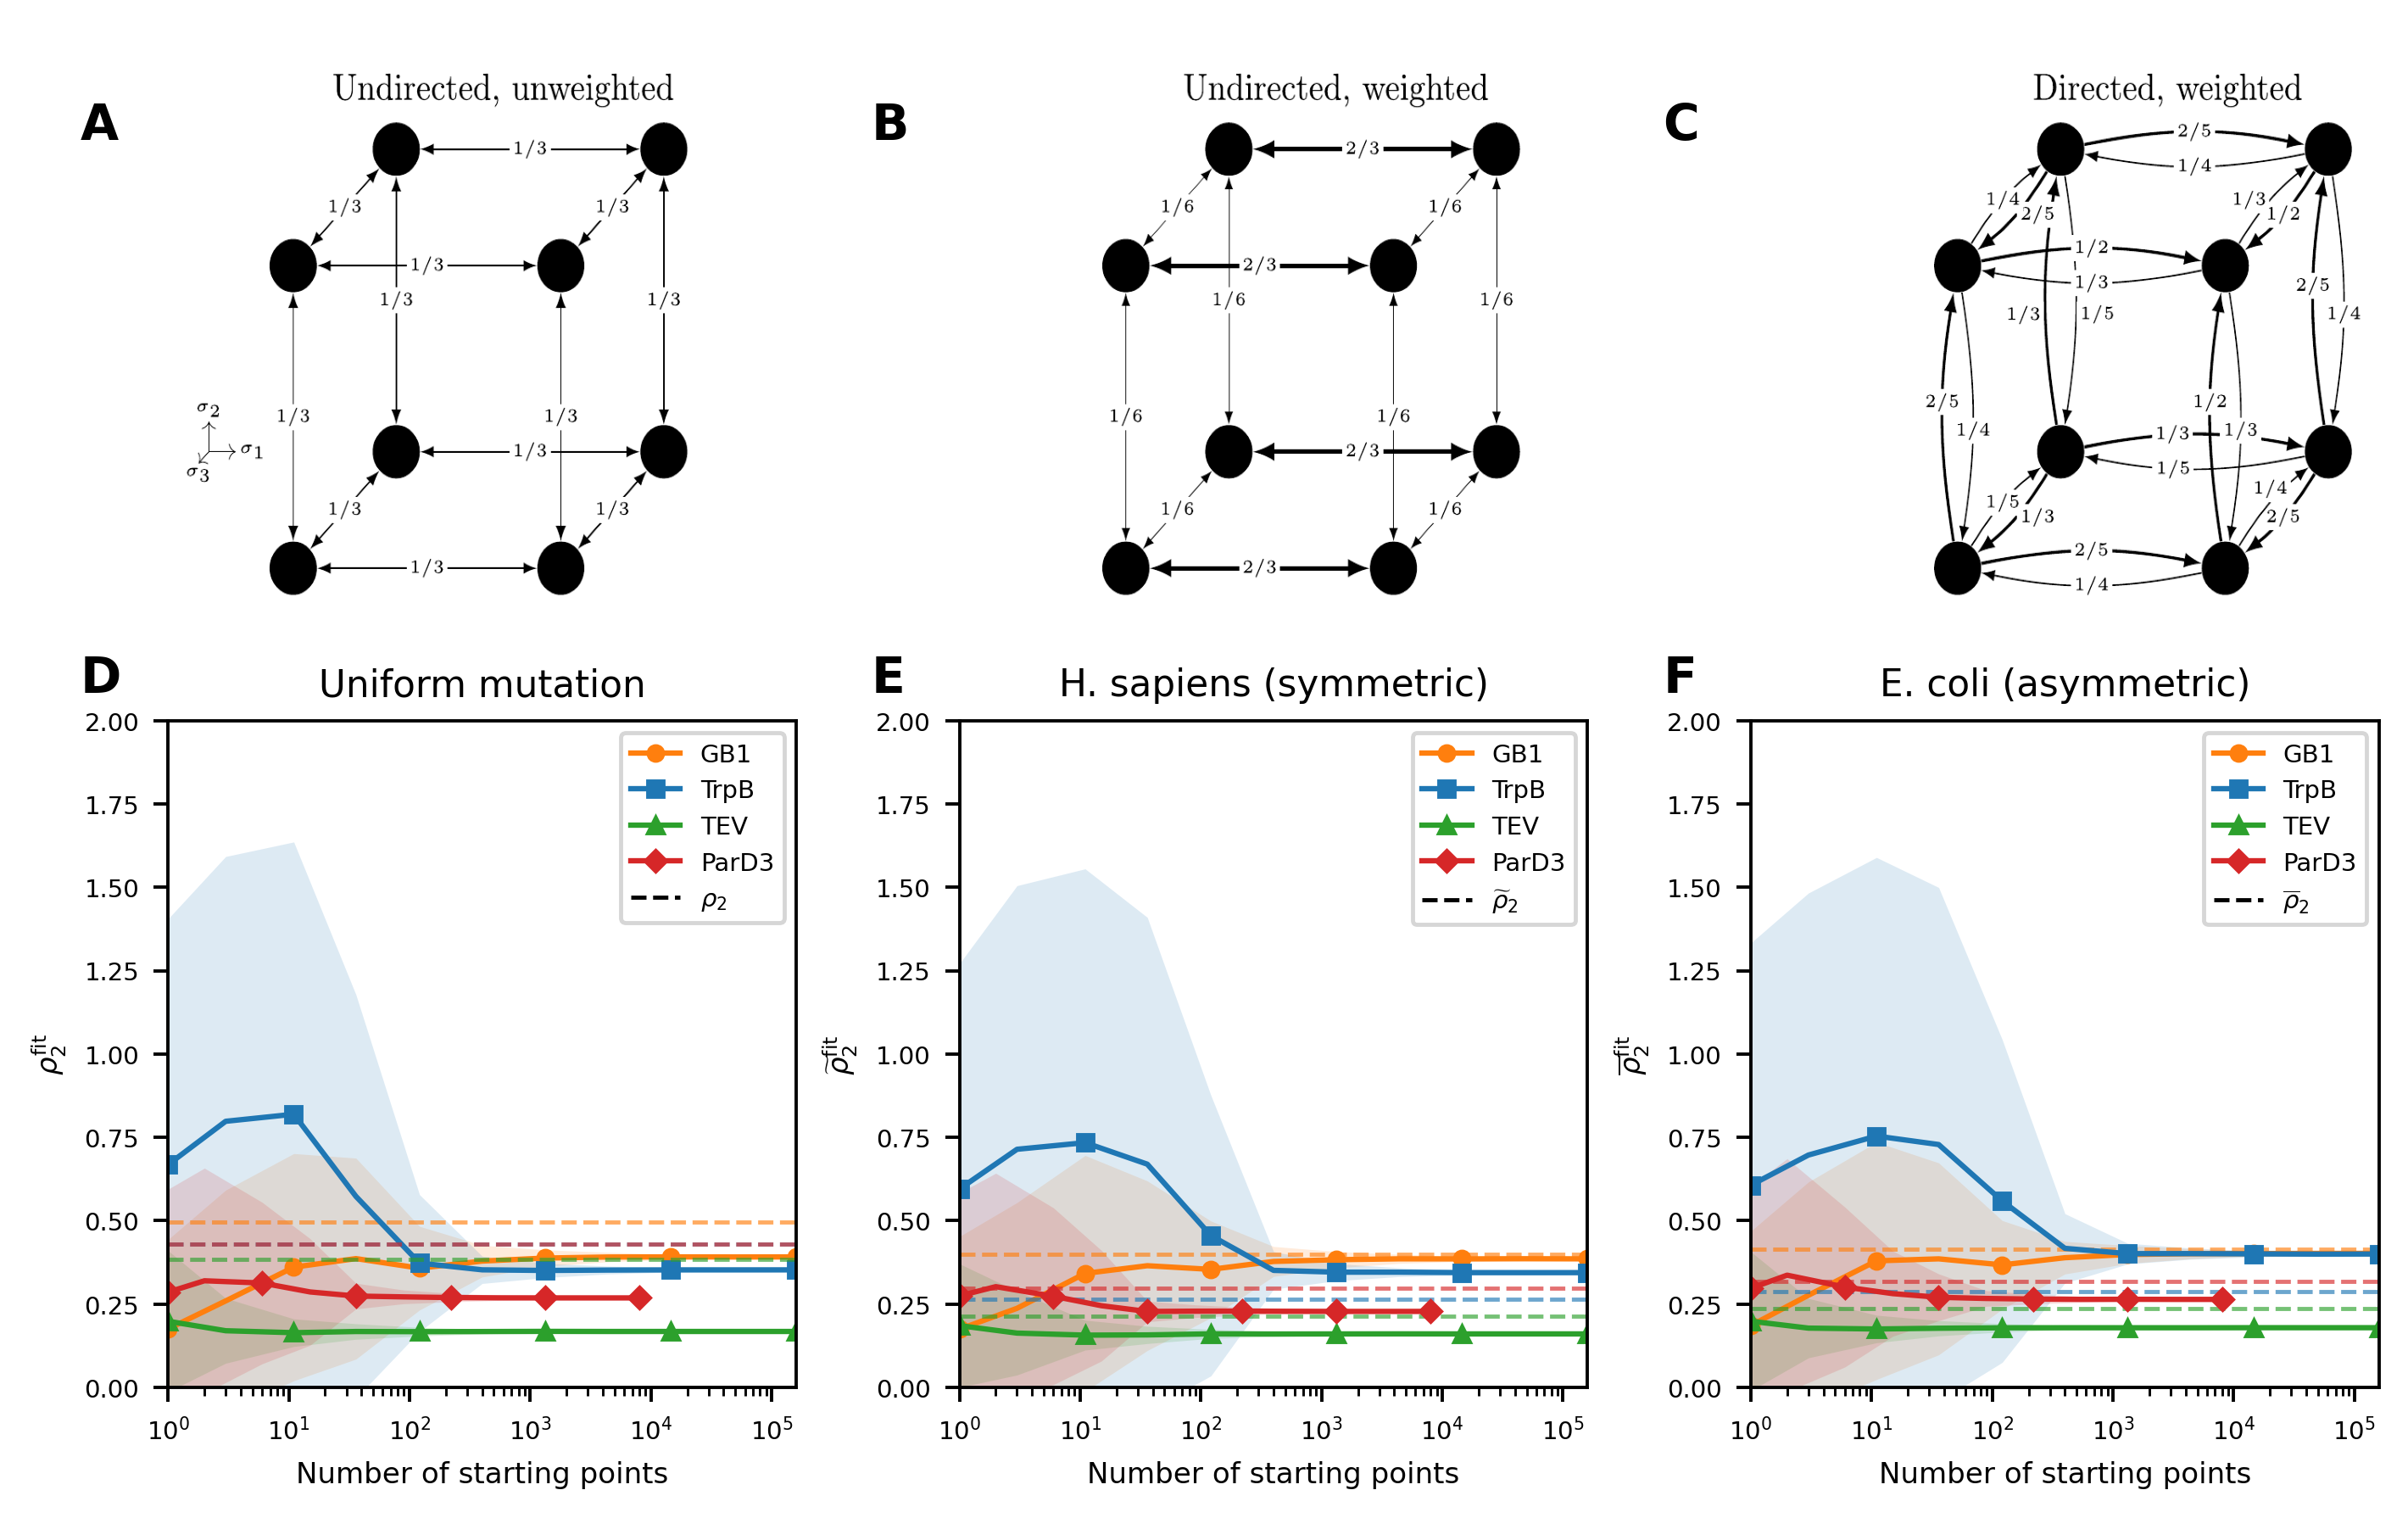

In [ ]:
mutation_graph_pdf = FIGURES_DIR / "graph_mutation_model.pdf"
if not mutation_graph_pdf.exists():
    raise FileNotFoundError(f"Missing mutation-model graph: {mutation_graph_pdf}")

mutation_graph_stem = Path(os.environ.get("TMPDIR", "/tmp")) / "slide_graph_mutation_model"
subprocess.run(
    [
        "pdftoppm",
        "-png",
        "-singlefile",
        "-r",
        "300",
        str(mutation_graph_pdf),
        str(mutation_graph_stem),
    ],
    check=True,
)
mutation_graph_image = plt.imread(mutation_graph_stem.with_suffix(".png"))

fig = plt.figure(figsize=(8, 5), dpi=PANEL_DPI, constrained_layout=True)
grid = GridSpec(2, 3, figure=fig, height_ratios=[0.9, 1.0])
graph_axes = [fig.add_subplot(grid[0, column]) for column in range(3)]
graph_width = mutation_graph_image.shape[1]
for column, (graph_ax, letter) in enumerate(zip(graph_axes, "ABC", strict=True)):
    left = round(column * graph_width / 3)
    right = round((column + 1) * graph_width / 3)
    graph_ax.imshow(mutation_graph_image[:, left:right], aspect="auto")
    graph_ax.axis("off")
    graph_ax.text(
        -0.14,
        0.85,
        letter,
        transform=graph_ax.transAxes,
        fontsize=PANEL_LETTER_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

axes = [fig.add_subplot(grid[1, column]) for column in range(3)]
for ax, letter, model in zip(axes, "DEF", MUTATION_MODELS, strict=True):
    plot_sampling_accuracy(ax, figure6_payload, model)
    add_panel_letter(ax, letter)

if SAVE_FIGURES:
    save_figure(fig, "figure_6")
plt.show()
